# Linear, Ridge and Lasso Regression Model

In [2]:
# Step 1: Import required Libaries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Step 2: Load the datset

df = pd.read_csv("ridge_regression.csv")

In [6]:
df.head()

,feature_1,feature_2_mc,feature_3_mc,feature_4,feature_5,feature_6_mc,feature_7,feature_8,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,target
0,67.548412,136.681113,74.904058,11.160537,394.588486,13.926652,-16.522447,0.421922,0.690173,0.130746,-0.231793,-0.007802,0.457751,1.374572,-0.677779,-0.196643,-1.541875,-0.968554,134.043083
1,10.584888,22.233329,10.508898,17.012526,162.191800,28.139002,-16.290166,0.096716,0.782327,-1.113222,0.568251,-1.514520,-2.619945,-0.606891,-0.915810,0.876012,0.664266,-1.219075,-26.813823
2,87.553621,172.345672,94.751066,2.291219,191.159310,3.137131,-10.688365,0.101001,-0.248490,1.399186,-0.635147,0.721966,0.198365,0.762765,1.332185,-0.560118,-0.474221,-0.387968,251.913937
3,75.621412,152.254209,84.322786,49.476168,355.999904,69.945374,13.714077,0.776000,0.033531,0.253237,-0.315592,0.723632,0.580780,2.321409,0.619968,-0.609403,-0.561798,-0.831581,169.374137
4,92.309283,183.101710,101.285729,12.331375,324.547254,18.179052,15.912915,0.399401,0.663990,3.401817,-0.435820,-0.026117,0.460988,0.140603,-1.233827,-1.272347,-0.319837,0.170221,317.867018


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   feature_1     1000 non-null   float64
 1   feature_2_mc  1000 non-null   float64
 2   feature_3_mc  1000 non-null   float64
 3   feature_4     1000 non-null   float64
 4   feature_5     1000 non-null   float64
 5   feature_6_mc  1000 non-null   float64
 6   feature_7     1000 non-null   float64
 7   feature_8     1000 non-null   float64
 8   noise_1       1000 non-null   float64
 9   noise_2       1000 non-null   float64
 10  noise_3       1000 non-null   float64
 11  noise_4       1000 non-null   float64
 12  noise_5       1000 non-null   float64
 13  noise_6       1000 non-null   float64
 14  noise_7       1000 non-null   float64
 15  noise_8       1000 non-null   float64
 16  noise_9       1000 non-null   float64
 17  noise_10      1000 non-null   float64
 18  target        1000 non-null   float64
dt

In [8]:
df.isnull().sum()

feature_1       0
feature_2_mc    0
feature_3_mc    0
feature_4       0
feature_5       0
feature_6_mc    0
feature_7       0
feature_8       0
noise_1         0
noise_2         0
noise_3         0
noise_4         0
noise_5         0
noise_6         0
noise_7         0
noise_8         0
noise_9         0
noise_10        0
target          0
dtype: int64

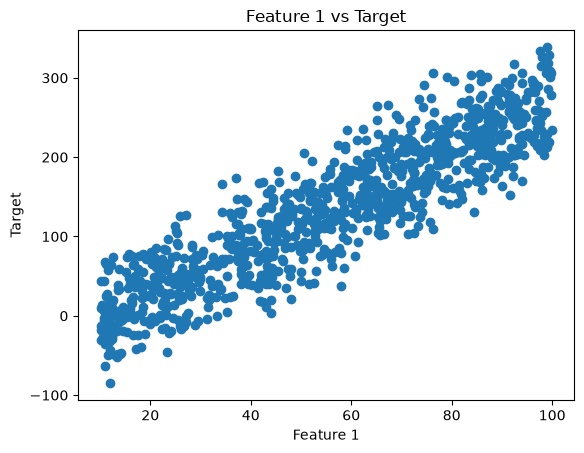

In [9]:
# Step 3: EDA

plt.scatter(df["feature_1"], df["target"])

plt.title("Feature 1 vs Target")
plt.xlabel("Feature 1")
plt.ylabel("Target")
plt.show()


In [10]:
# Step 4: Creating X and y variables 

X = df.drop("target", axis=1)

y = df["target"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression

# Create the instance of model
LR = LinearRegression()

# Train the model
model = LR.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Find the MSE
MSE = mean_squared_error(y_test, y_pred)

# Find the MAE
MAE = mean_absolute_error(y_test, y_pred)

# Find the R2 score
r2 = r2_score(y_test, y_pred)

print(f"MSE : {MSE}")
print(f"MAE : {MAE}")
print(f"R2_Score : {r2}")

MSE : 260.6851823053078
MAE : 12.996323934200937
R2_Score : 0.9674605691991364


In [14]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [18]:
# Create the instance of model
RR = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

# Train the model
model = RR.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Find the MSE
MSE = mean_squared_error(y_test, y_pred)

# Find the MAE
MAE = mean_absolute_error(y_test, y_pred)

# Find the R2 score
r2 = r2_score(y_test, y_pred)

print(f"MSE : {MSE}")
print(f"MAE : {MAE}")
print(f"R2_Score : {r2}")

MSE : 257.0699093936615
MAE : 12.968028503183191
R2_Score : 0.9679118373598138


In [19]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [21]:
# Create the instance of model
LS = make_pipeline(
    StandardScaler(),
    Lasso(alpha=1.0, max_iter=10000)
)

# Train the model
model = LS.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Find the MSE
MSE = mean_squared_error(y_test, y_pred)

# Find the MAE
MAE = mean_absolute_error(y_test, y_pred)

# Find the R2 score
r2 = r2_score(y_test, y_pred)

print(f"MSE : {MSE}")
print(f"MAE : {MAE}")
print(f"R2_Score : {r2}")

MSE : 266.61380664136266
MAE : 13.018044700750497
R2_Score : 0.96672054224547


In [23]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],

    "MSE": [
        mean_squared_error(y_test, LR.predict(X_test)),
        mean_squared_error(y_test, RR.predict(X_test)),
        mean_squared_error(y_test, LS.predict(X_test))
    ],

    "MAE": [
        mean_absolute_error(y_test, LR.predict(X_test)),
        mean_absolute_error(y_test, RR.predict(X_test)),
        mean_absolute_error(y_test, LS.predict(X_test))
    ],

    "R2 Score": [
        r2_score(y_test, LR.predict(X_test)),
        r2_score(y_test, RR.predict(X_test)),
        r2_score(y_test, LS.predict(X_test))
    ]
})

print(results)

               Model         MSE        MAE  R2 Score
0  Linear Regression  260.685182  12.996324  0.967461
1   Ridge Regression  257.069909  12.968029  0.967912
2   Lasso Regression  266.613807  13.018045  0.966721
